# DSC 6016 Assignment 1
## Air Passengers Time Series Analysis

## Overview

### 1. Data Loading and Initial Inspection
  # 1.1 Import Libraries
  # 1.2 Load Dataset
  # 1.3 Initial Inspection

### 2. Data Cleaning

### 3. Exploratory Data Analysis
  # 3.1 Time Series Plot
  # 3.2 Histogram
  # 3.3 Summary Statistics

### 4. Deterministic Trend Model
  # 4.1 Create a Time Index
  # 4.2 Fit a Linear Trend Model
  # 4.3 Trend Model Results and Visualization

### 5. Seasonality Analysis
  # 5.1 Create Monthly Seasonal Indicators
  # 5.2 Seasonal Plot
  # 5.3 Average Passenger Count by Month
  # 5.4 Detrended Autocorrelation Analysis

### 6. Seasonality Model
  # 6.1 Create Monthly Seasonal Dummy Variables
  # 6.2 Fit the Trend + Seasonality Model
  # 6.3 Seasonal Coefficients
  # 6.4 Observed vs Fitted

### 7. Residual Analysis
  # 7.1 Calculate Model Residuals
  # 7.2 Residual Time Series
  # 7.3 Residual Distribution
  # 7.4 Autocorrelation of Residuals
  # 7.5 Model Error Metrics
  # 7.6 Ljung–Box Test

### 8. Log Transformation and Alternative Model
  # 8.1 Log Transformation
  # 8.2 Log-Transformed Time Series
  # 8.3 Fit the Log-Scale Model
  # 8.4 Back-Transformed Fitted Values
  # 8.5 Log-Scale Residual ACF
  # 8.6 Ljung–Box Test
  # 8.7 Model Comparison Figure

### 9. Model Comparison and Final Results
  # 9.1 Overall Model Fit
  # 9.2 Seasonal Residual Diagnostics
  # 9.3 Original-Scale Error Comparison
  # 9.4 Improvement in Error Metrics
  # 9.5 Evidence of Annual Seasonality

## 10. Conclusion

### 1. Data Loading and Initial Inspection

# 1.1 Import libraries

In [1]:
# 1.1 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

# 1.2 Load dataset

In [2]:
# 1.2 Load dataset
df = pd.read_csv("data/AirPassengers.csv")

# 1.3 Initial inspection

In [3]:
# 1.3 Initial inspection
print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (144, 2)


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        144 non-null    str  
 1   #Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [5]:
#Summary statistics
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [6]:
#Check missing values
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

### 2. Data Cleaning

In [7]:
# 2. Data Cleaning

# Convert Month to datetime
df['Month'] = pd.to_datetime(
    df['Month'],
    format='%Y-%m'
)

# Rename the passenger column
df = df.rename(
    columns={'#Passengers': 'Passengers'}
)

# Sort observations chronologically
df = df.sort_values(
    'Month'
).reset_index(drop=True)

### 3. Exploratory Data Analysis

# 3.1 Time Series Plot

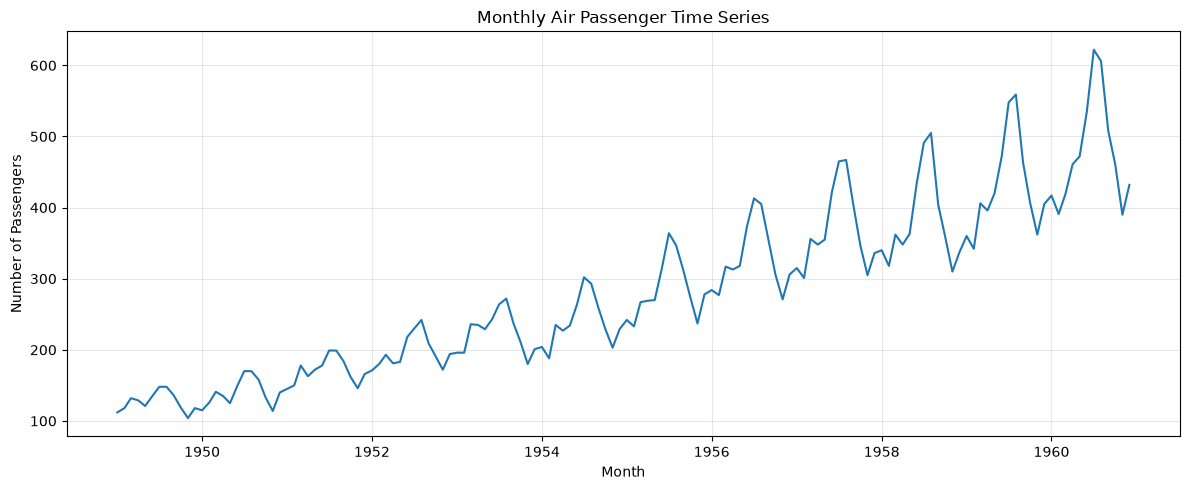

In [8]:
# 3.1 Time Series Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    df['Month'],
    df['Passengers'],
    linewidth=1.5
)

plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Monthly Air Passenger Time Series')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/time_series.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 3.2 Histogram

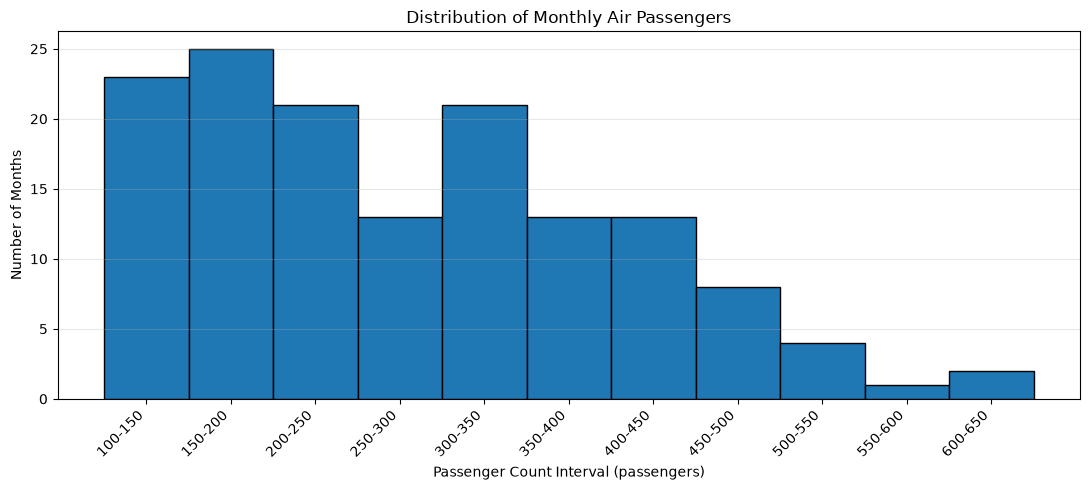

In [9]:
# 3.2 Histogram
#Define meaningful 50-passenger intervals
bins = np.arange(100, 651, 50)

#Calculate frequencies for each interval
counts, edges = np.histogram(df['Passengers'], bins=bins)

#Calculate the center of each bar
centers = (edges[:-1] + edges[1:]) / 2

#Create interval labels
labels = [
    f'{int(edges[i])}-{int(edges[i+1])}'
    for i in range(len(edges) - 1)
]

plt.figure(figsize=(11, 5))

plt.hist(
    df['Passengers'],
    bins=bins,
    edgecolor='black'
)

#X-axis: label each interval
plt.xticks(
    centers,
    labels,
    rotation=45,
    ha='right'
)

plt.xlabel('Passenger Count Interval (passengers)')
plt.ylabel('Number of Months')
plt.title('Distribution of Monthly Air Passengers')

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/histogram.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 4. Deterministic Trend Model

# 4.1 Create a Time Index

In [10]:
# 4.1 Create a Time Index

# Create a sequential time index
df['t'] = range(1, len(df) + 1)

# 4.2 Fit a Linear Trend Model

In [11]:
# 4.2 Fit a Linear Trend Model
import statsmodels.api as sm

# Define the independent variable (time)
X = sm.add_constant(df['t'])

# Define the dependent variable
y = df['Passengers']

# Fit the Ordinary Least Squares (OLS) regression model
trend_model = sm.OLS(y, X).fit()

# Display the complete regression results
print(trend_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Passengers   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     828.2
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           4.02e-61
Time:                        17:21:35   Log-Likelihood:                -754.82
No. Observations:                 144   AIC:                             1514.
Df Residuals:                     142   BIC:                             1520.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         87.6528      7.716     11.359      0.0

# 4.3 Trend Model Results and Visualization

Linear Trend Model
------------------
Intercept (β₀): 87.6528
Trend coefficient (β₁): 2.6572
R-squared: 0.8536
P-value for trend: 0.000000

Estimated Trend Equation
------------------------
Passengers = 87.6528 + 2.6572 × t


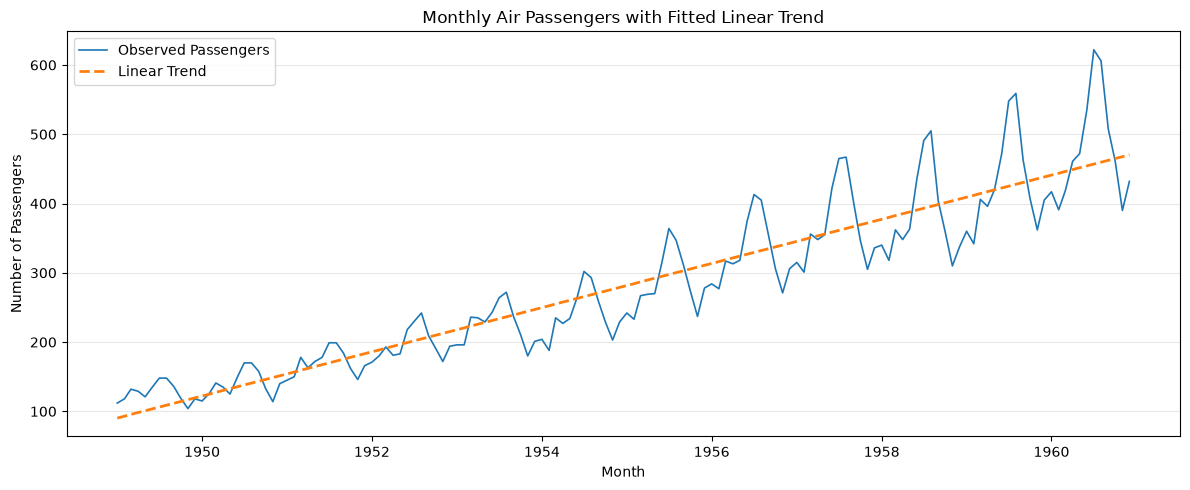

In [12]:
# 4.3 Trend Model Results and Visualization

# Extract key model statistics
intercept = trend_model.params['const']
slope = trend_model.params['t']
r_squared = trend_model.rsquared
p_value = trend_model.pvalues['t']

# Display key model results
print("Linear Trend Model")
print("------------------")
print(f"Intercept (β₀): {intercept:.4f}")
print(f"Trend coefficient (β₁): {slope:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value for trend: {p_value:.6f}")

# Display the estimated trend equation
print("\nEstimated Trend Equation")
print("------------------------")
print(f"Passengers = {intercept:.4f} + {slope:.4f} × t")


# Generate fitted trend values
df['Trend'] = trend_model.predict(X)


# Plot observed values and fitted trend
plt.figure(figsize=(12, 5))

plt.plot(
    df['Month'],
    df['Passengers'],
    linewidth=1.2,
    label='Observed Passengers'
)

plt.plot(
    df['Month'],
    df['Trend'],
    linewidth=2,
    linestyle='--',
    label='Linear Trend'
)

plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Monthly Air Passengers with Fitted Linear Trend')

plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/trend_model.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 5. Seasonality Analysis

# 5.1 Create Monthly Seasonal Indicators

In [13]:
# 5.1 Create Monthly Seasonal Indicators

# Create month and year variables
df['Month_Number'] = df['Month'].dt.month
df['Year'] = df['Month'].dt.year

# 5.2 Seasonal Plot

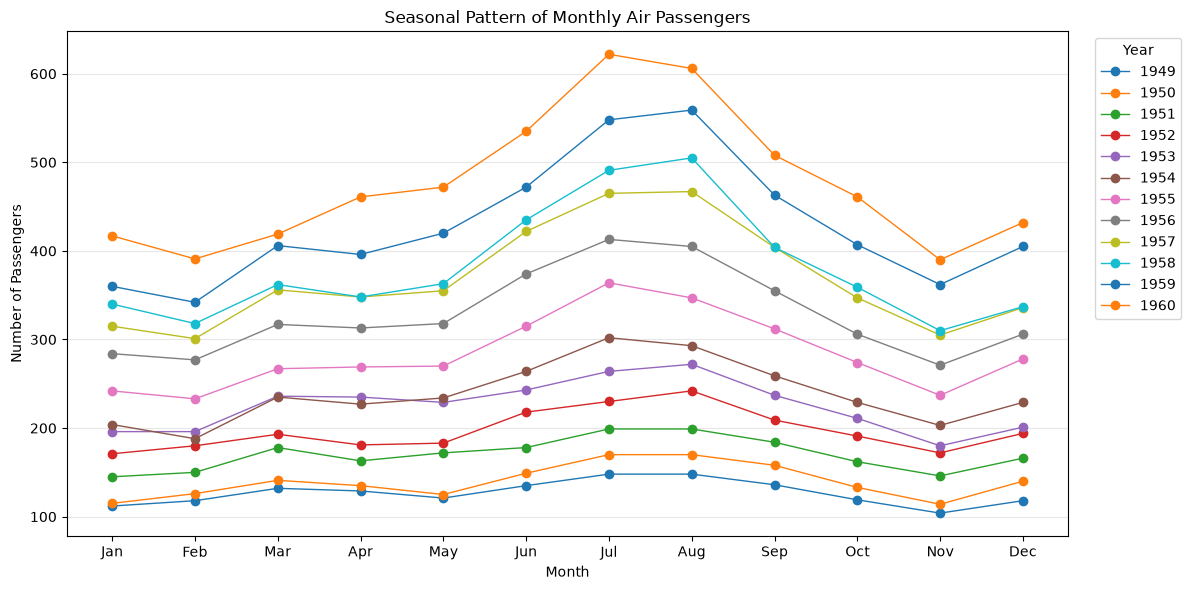

In [14]:
# 5.2 Seasonal Plot

# 5.2 Seasonal Plot
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(12, 6))

for year, group in df.groupby('Year'):
    plt.plot(
        group['Month_Number'],
        group['Passengers'],
        marker='o',
        linewidth=1,
        label=str(year)
    )

plt.xticks(
    range(1, 13),
    month_labels
)

plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Seasonal Pattern of Monthly Air Passengers')

# Add a legend for the 12 years
plt.legend(
    title='Year',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    ncol=1
)

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/seasonal_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 5.3 Average Passenger Count by Month

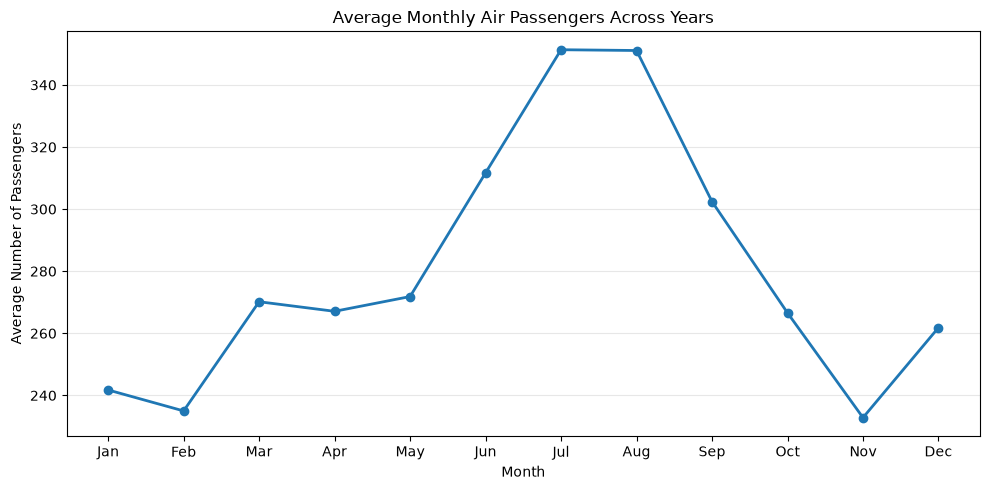

In [15]:
# 5.3 Average Passenger Count by Month

# Calculate the average passenger count for each calendar month
monthly_avg = (
    df.groupby('Month_Number')['Passengers']
      .mean()
)

monthly_avg

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    linewidth=2
)

plt.xticks(
    range(1, 13),
    month_labels
)

plt.xlabel('Month')
plt.ylabel('Average Number of Passengers')
plt.title('Average Monthly Air Passengers Across Years')

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/monthly_seasonal_pattern.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 5.4 Autocorrelation Analysis
#To examine seasonality more clearly, the linear trend is removed before calculating the autocorrelation function (ACF). For monthly data, particular attention is given to lags 12, 24, and 36, which correspond to annual cycles.

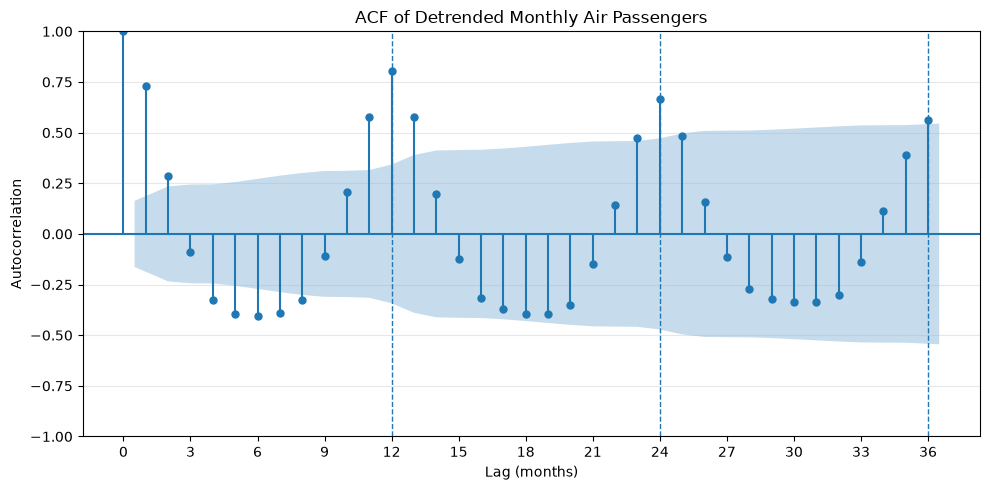

In [16]:
# 5.4 Autocorrelation Analysis
from statsmodels.graphics.tsaplots import plot_acf

# Remove the fitted linear trend
df['Detrended_Passengers'] = df['Passengers'] - df['Trend']

# Create ACF plot
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    df['Detrended_Passengers'],
    lags=36,
    alpha=0.05,
    fft=False,
    ax=ax
)

# Highlight the annual seasonal lags
for lag in [12, 24, 36]:
    ax.axvline(
        lag,
        linestyle='--',
        linewidth=1
    )

ax.set_xticks(range(0, 37, 3))
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of Detrended Monthly Air Passengers')

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/acf_detrended.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 6. Seasonality Model

# 6.1 Create Monthly Seasonal Dummy Variables

In [17]:
# 6.1 Create Monthly Seasonal Dummy Variables

# Create 11 monthly dummy variables.
# January is used as the reference month.
month_dummies = pd.get_dummies(
    df['Month_Number'],
    prefix='Month',
    drop_first=True
).astype(float)

month_dummies.head()

# Combine the time trend and monthly seasonal variables

X_seasonal = pd.concat(
    [
        df[['t']],
        month_dummies
    ],
    axis=1
)

# Add the intercept
X_seasonal = sm.add_constant(X_seasonal)

X_seasonal.head()

,const,t,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 6.2 Fit the Trend + Seasonality Model
# Fit an OLS regression including:
# 1. A linear time trend
# 2. Monthly seasonal dummy variables

In [18]:
# 6.2 Fit the Trend + Seasonality Model

seasonal_model = sm.OLS(
    y,
    X_seasonal
).fit()

# Generate fitted values immediately after fitting the model
df['Seasonal_Fitted'] = seasonal_model.predict(
    X_seasonal
)

# Display the full regression results
print(seasonal_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Passengers   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     236.5
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.71e-82
Time:                        17:21:37   Log-Likelihood:                -668.50
No. Observations:                 144   AIC:                             1363.
Df Residuals:                     131   BIC:                             1402.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.5079      8.389      7.571      0.0

# 6.3 Compare the trend-only model with the seasonal model

In [19]:
# 6.3 Compare the trend-only model with the seasonal model
# Display the estimated monthly seasonal effects

seasonal_coefficients = seasonal_model.params[
    seasonal_model.params.index.str.startswith('Month_')
]

seasonal_pvalues = seasonal_model.pvalues[
    seasonal_model.pvalues.index.str.startswith('Month_')
]

seasonal_results = pd.DataFrame({
    'Coefficient': seasonal_coefficients,
    'P-value': seasonal_pvalues
})

seasonal_results



,Coefficient,P-value
Month_2,-9.410329,3.829437e-01
Month_3,23.096008,3.351308e-02
Month_4,17.352346,1.089113e-01
Month_5,19.442016,7.284910e-02
Month_6,56.615020,5.577727e-07
Month_7,93.621358,1.172346e-14
Month_8,90.711029,5.322095e-14
Month_9,39.384033,3.631761e-04
Month_10,0.890370,9.341772e-01
Month_11,-35.519959,1.244009e-03


# 6.4 Plot the observed series and fitted trend + seasonality model

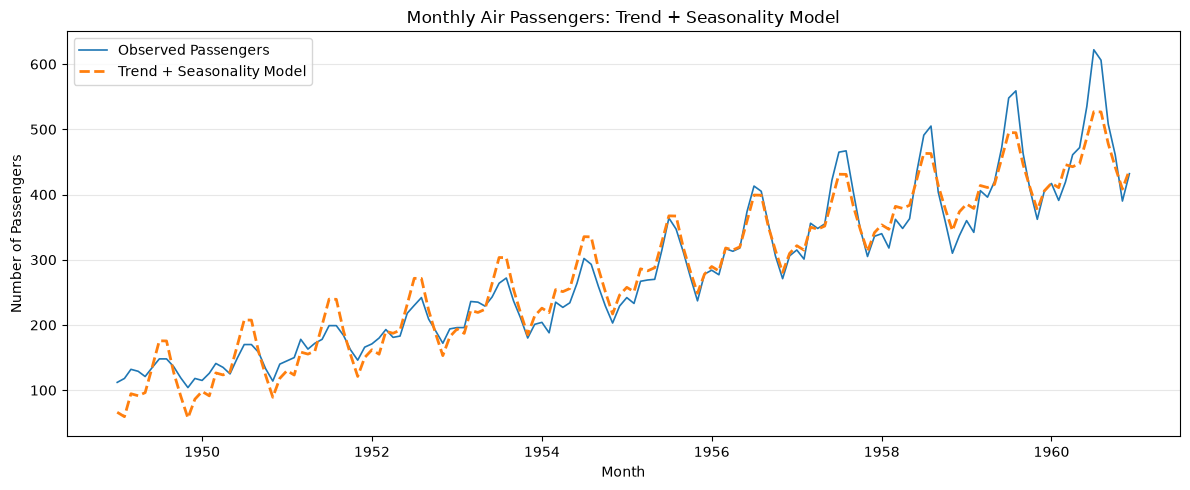

In [20]:
# 6.4 Plot the observed series and fitted trend + seasonality model

plt.figure(figsize=(12, 5))

plt.plot(
    df['Month'],
    df['Passengers'],
    linewidth=1.2,
    label='Observed Passengers'
)

plt.plot(
    df['Month'],
    df['Seasonal_Fitted'],
    linewidth=2,
    linestyle='--',
    label='Trend + Seasonality Model'
)

plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title(
    'Monthly Air Passengers: Trend + Seasonality Model'
)

plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/trend_seasonality_model.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 7. Residual Analysis

# 7.1 Calculate model residuals

In [21]:
# 7.1 Calculate model residuals

df['Residual'] = (
    df['Passengers'] - df['Seasonal_Fitted']
)

In [22]:
print(f"Mean residual: {df['Residual'].mean():.6f}")

Mean residual: 0.000000


# 7.2 Plot residuals over time

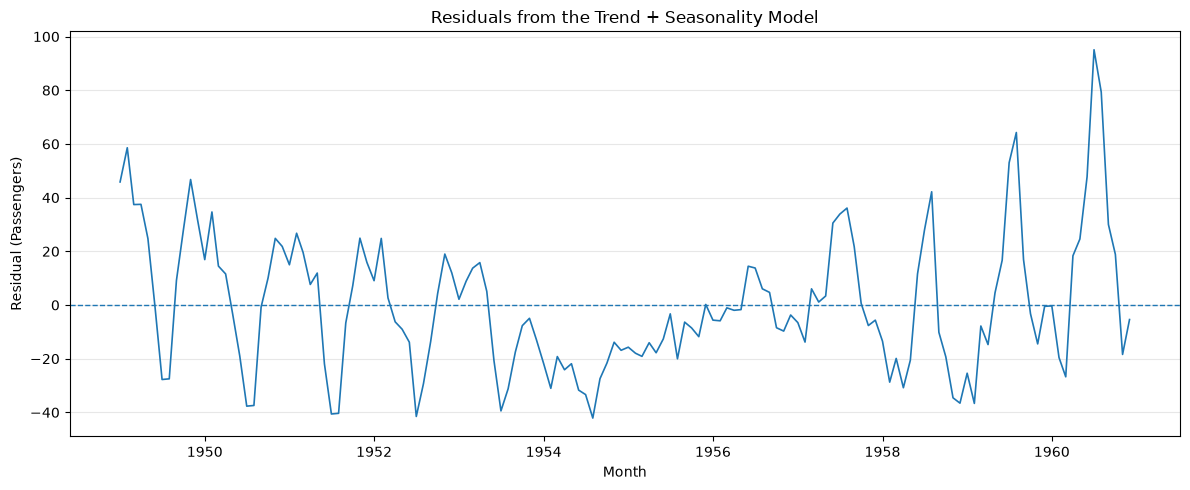

In [23]:
# 7.2 Plot residuals over time

plt.figure(figsize=(12, 5))

plt.plot(
    df['Month'],
    df['Residual'],
    linewidth=1.2
)

# Add a horizontal zero reference line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Month')
plt.ylabel('Residual (Passengers)')
plt.title('Residuals from the Trend + Seasonality Model')

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/residual_time_series.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 7.3 Histogram of residuals

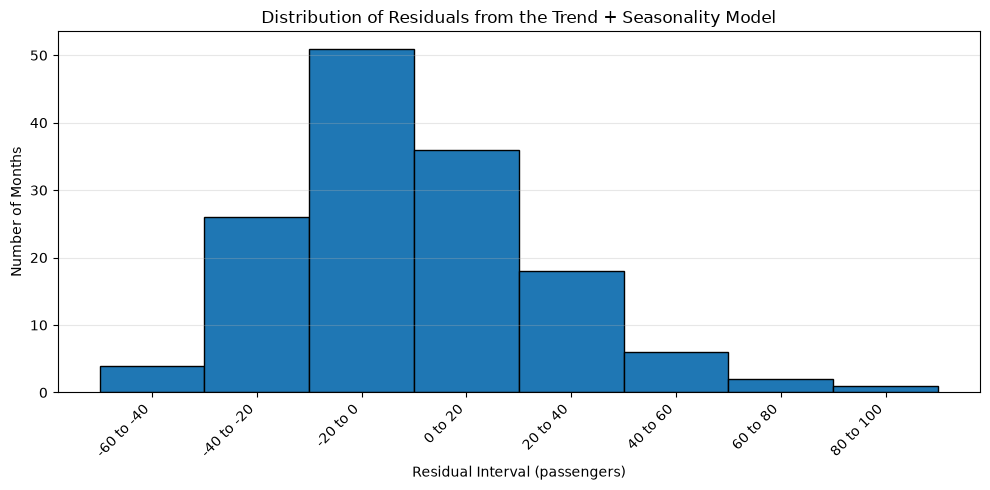

In [24]:
# 7.3 Histogram of residuals

import numpy as np
import matplotlib.pyplot as plt

# Define the histogram bin width
bin_width = 20

# Create meaningful residual intervals based on the observed range
lower_bound = np.floor(df['Residual'].min() / bin_width) * bin_width
upper_bound = np.ceil(df['Residual'].max() / bin_width) * bin_width

bins = np.arange(
    lower_bound,
    upper_bound + bin_width,
    bin_width
)

# Create the histogram
plt.figure(figsize=(10, 5))

plt.hist(
    df['Residual'],
    bins=bins,
    edgecolor='black'
)

# Calculate bin centers for x-axis labels
centers = (bins[:-1] + bins[1:]) / 2

# Create explicit interval labels
labels = [
    f'{int(bins[i])} to {int(bins[i + 1])}'
    for i in range(len(bins) - 1)
]

plt.xticks(
    centers,
    labels,
    rotation=45,
    ha='right'
)

plt.xlabel('Residual Interval (passengers)')
plt.ylabel('Number of Months')
plt.title('Distribution of Residuals from the Trend + Seasonality Model')

plt.grid(
    True,
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    'figures/residual_histogram.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 7.4 ACF of residuals

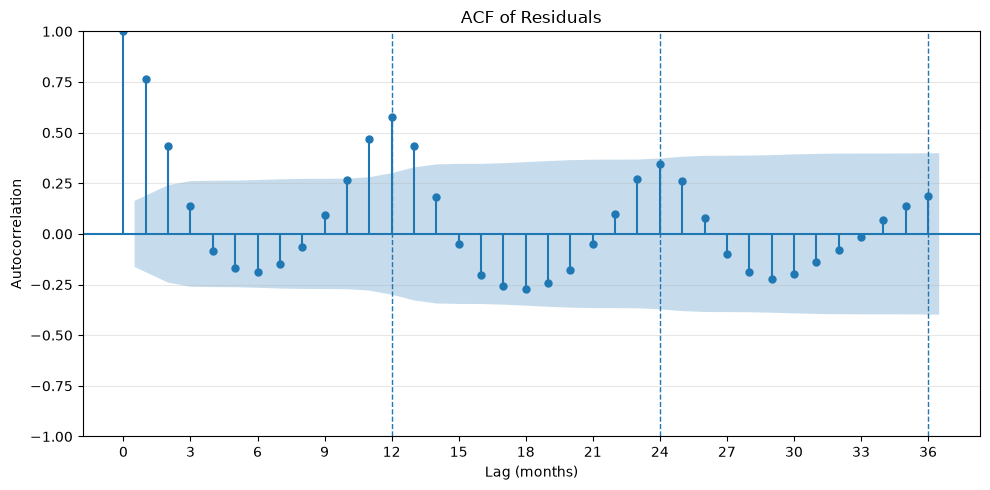

Key Residual Autocorrelations
-----------------------------
Lag 12: 0.5780
Lag 24: 0.3460
Lag 36: 0.1856


In [25]:
# 7.4 ACF of residuals

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Calculate ACF values for the model residuals
acf_values = acf(
    df['Residual'],
    nlags=36,
    fft=False
)

# Plot the residual ACF
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    df['Residual'],
    lags=36,
    alpha=0.05,
    fft=False,
    ax=ax
)

# Highlight the annual seasonal lags
for lag in [12, 24, 36]:
    ax.axvline(
        lag,
        linestyle='--',
        linewidth=1
    )

ax.set_xticks(range(0, 37, 3))
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of Residuals')

ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'figures/residual_acf.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# Display key autocorrelation values
print("Key Residual Autocorrelations")
print("-----------------------------")
print(f"Lag 12: {acf_values[12]:.4f}")
print(f"Lag 24: {acf_values[24]:.4f}")
print(f"Lag 36: {acf_values[36]:.4f}")

# 7.5 Calculate RMSE and MAE

In [26]:
# 7.5 Calculate RMSE and MAE

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = mean_squared_error(
    df['Passengers'],
    df['Seasonal_Fitted']
) ** 0.5

mae = mean_absolute_error(
    df['Passengers'],
    df['Seasonal_Fitted']
)

print("Trend + Seasonality Model Error Metrics")
print("----------------------------------------")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

Trend + Seasonality Model Error Metrics
----------------------------------------
RMSE: 25.1136
MAE: 19.7736


# 7.6 Ljung-Box test for residual autocorrelation

In [27]:
# 7.6 Ljung-Box test for residual autocorrelation

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    df['Residual'],
    lags=[12, 24, 36],
    return_df=True
)

print("Ljung-Box Test for Residual Autocorrelation")
print("--------------------------------------------")
print(lb_test)

Ljung-Box Test for Residual Autocorrelation
--------------------------------------------
       lb_stat     lb_pvalue
12  231.496701  9.739278e-43
24  348.241172  2.862530e-59
36  401.951032  2.280211e-63


### 8. Log Transformation and Alternative Seasonal Model

# 8.1 Log transformation

In [28]:
# 8.1 Log transformation
# Apply natural logarithm to the passenger series
df['Log_Passengers'] = np.log(df['Passengers'])

# 8.2 Plot the log-transformed time series

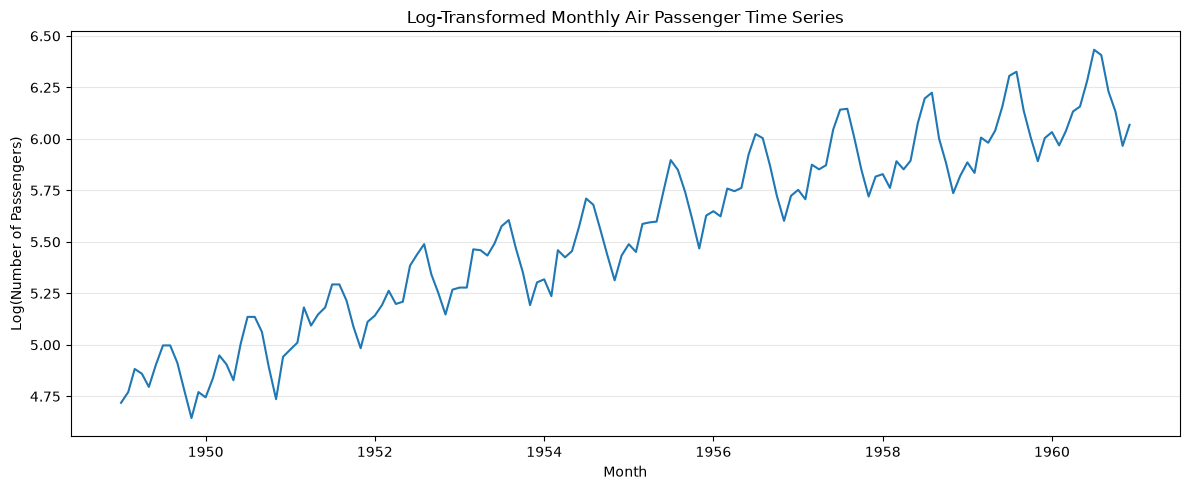

In [29]:
# 8.2 Plot the log-transformed time series

plt.figure(figsize=(12, 5))

plt.plot(
    df['Month'],
    df['Log_Passengers'],
    linewidth=1.5
)

plt.xlabel('Month')
plt.ylabel('Log(Number of Passengers)')
plt.title('Log-Transformed Monthly Air Passenger Time Series')

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/log_time_series.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 8.3 Fit the log-scale trend + seasonality model

In [30]:
# 8.3 Fit the log-scale trend + seasonality model

# Define the log-transformed dependent variable
log_y = df['Log_Passengers']

# Fit OLS using the same trend and seasonal variables
log_seasonal_model = sm.OLS(
    log_y,
    X_seasonal
).fit()

# Display the full regression results
print(log_seasonal_model.summary())

                            OLS Regression Results                            
Dep. Variable:         Log_Passengers   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     649.4
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          2.31e-110
Time:                        17:21:40   Log-Likelihood:                 209.30
No. Observations:                 144   AIC:                            -392.6
Df Residuals:                     131   BIC:                            -354.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7268      0.019    250.180      0.0

In [31]:
# Extract key statistics from the log-scale model

log_intercept = log_seasonal_model.params['const']
log_slope = log_seasonal_model.params['t']
log_r_squared = log_seasonal_model.rsquared
log_adj_r_squared = log_seasonal_model.rsquared_adj
log_aic = log_seasonal_model.aic
log_bic = log_seasonal_model.bic

print("Log-Scale Trend + Seasonality Model")
print("-----------------------------------")
print(f"R-squared: {log_r_squared:.4f}")
print(f"Adjusted R-squared: {log_adj_r_squared:.4f}")
print(f"AIC: {log_aic:.2f}")
print(f"BIC: {log_bic:.2f}")

Log-Scale Trend + Seasonality Model
-----------------------------------
R-squared: 0.9835
Adjusted R-squared: 0.9820
AIC: -392.60
BIC: -353.99


In [32]:
# Generate fitted log-scale values
df['Log_Fitted'] = log_seasonal_model.predict(
    X_seasonal
)

df[['Month', 'Log_Passengers', 'Log_Fitted']].head(12)

,Month,Log_Passengers,Log_Fitted
0,1949-01-01,4.718499,4.736849
1,1949-02-01,4.770685,4.724863
2,1949-03-01,4.882802,4.865159
3,1949-04-01,4.859812,4.843959
4,1949-05-01,4.795791,4.851655
5,1949-06-01,4.905275,4.983870
6,1949-07-01,4.997212,5.097881
7,1949-08-01,4.997212,5.098655
8,1949-09-01,4.912655,4.964090
9,1949-10-01,4.779123,4.836000


In [33]:
# Convert fitted values back to the original passenger scale

df['Log_Fitted_Passengers'] = np.exp(
    df['Log_Fitted']
)

df[['Month', 'Passengers', 'Log_Fitted_Passengers']].head(12)

,Month,Passengers,Log_Fitted_Passengers
0,1949-01-01,112,114.074207
1,1949-02-01,118,112.715073
2,1949-03-01,132,129.691568
3,1949-04-01,129,126.971040
4,1949-05-01,121,127.952000
5,1949-06-01,135,146.038488
6,1949-07-01,148,163.674767
7,1949-08-01,148,163.801495
8,1949-09-01,136,143.178127
9,1949-10-01,119,125.964493


# 8.4 Plot observed values and fitted values

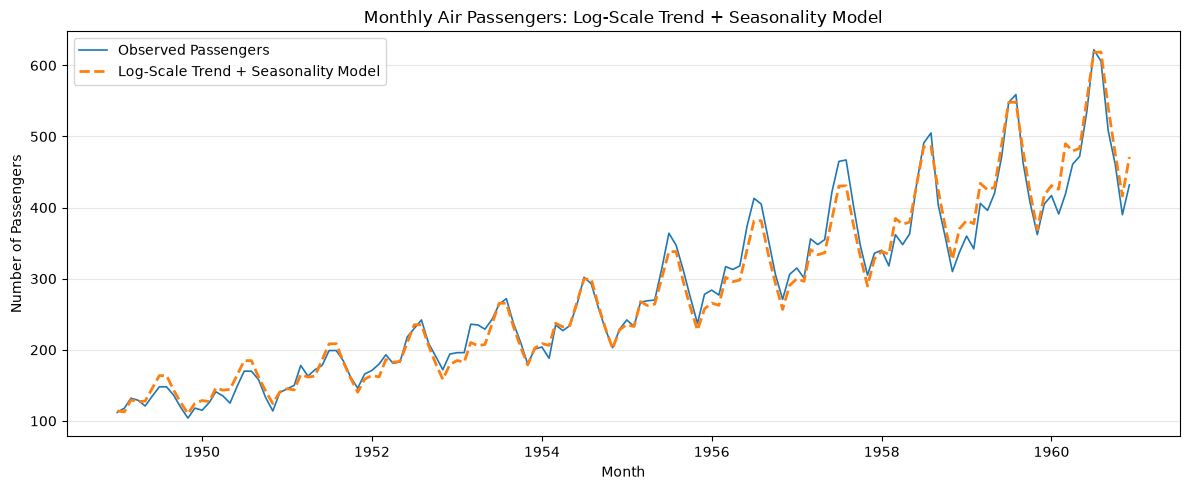

In [34]:
# 8.4 Plot observed values and fitted values
# from the log-scale model after back-transformation

plt.figure(figsize=(12, 5))

plt.plot(
    df['Month'],
    df['Passengers'],
    linewidth=1.2,
    label='Observed Passengers'
)

plt.plot(
    df['Month'],
    df['Log_Fitted_Passengers'],
    linewidth=2,
    linestyle='--',
    label='Log-Scale Trend + Seasonality Model'
)

plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title(
    'Monthly Air Passengers: Log-Scale Trend + Seasonality Model'
)

plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'figures/log_trend_seasonality_model.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [35]:
# Calculate residuals for the log-scale model

df['Log_Residual'] = (
    df['Log_Passengers'] - df['Log_Fitted']
)

print(
    f"Mean log residual: "
    f"{df['Log_Residual'].mean():.6f}"
)

Mean log residual: 0.000000


# 8.5 Residual ACF of the log-scale model

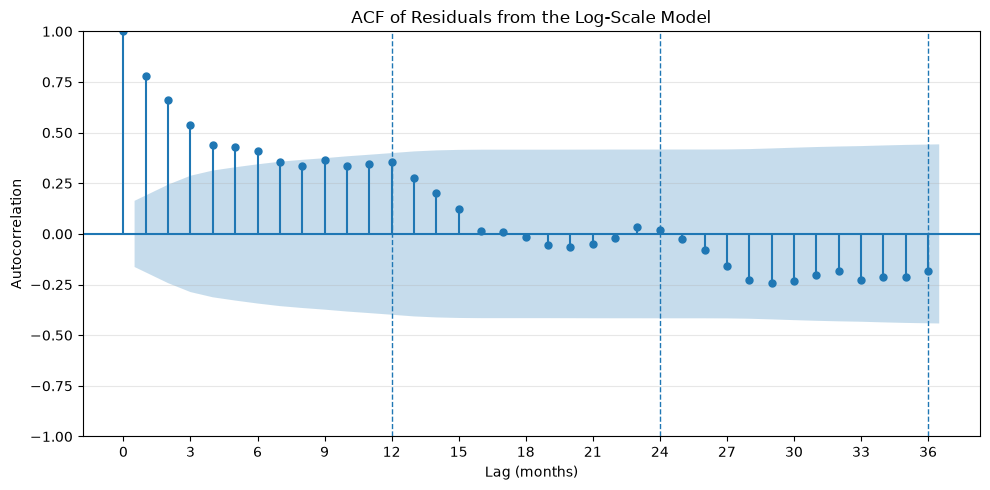

Key Log-Scale Residual Autocorrelations
----------------------------------------
Lag  1: 0.7788
Lag  6: 0.4096
Lag 12: 0.3531
Lag 18: -0.0169
Lag 24: 0.0195
Lag 30: -0.2302
Lag 36: -0.1837


In [36]:
# 8.5 Residual ACF of the log-scale model

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Calculate ACF values
log_acf_values = acf(
    df['Log_Residual'],
    nlags=36,
    fft=False
)

# Plot residual ACF
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    df['Log_Residual'],
    lags=36,
    alpha=0.05,
    fft=False,
    ax=ax
)

# Highlight annual seasonal lags
for lag in [12, 24, 36]:
    ax.axvline(
        lag,
        linestyle='--',
        linewidth=1
    )

ax.set_xticks(range(0, 37, 3))
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
ax.set_title(
    'ACF of Residuals from the Log-Scale Model'
)

ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'figures/log_residual_acf.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# Display key seasonal autocorrelations
key_lags = [1, 6, 12, 18, 24, 30, 36]

print("Key Log-Scale Residual Autocorrelations")
print("----------------------------------------")

for lag in key_lags:
    print(
        f"Lag {lag:>2}: "
        f"{log_acf_values[lag]:.4f}"
    )

# 8.6 Ljung-Box test for the log-scale model residuals

In [37]:
# 8.6 Ljung-Box test for the log-scale model residuals

log_lb_test = acorr_ljungbox(
    df['Log_Residual'],
    lags=[12, 24, 36],
    return_df=True
)

print("Ljung-Box Test for Log-Scale Model Residuals")
print("---------------------------------------------")
print(log_lb_test)

Ljung-Box Test for Log-Scale Model Residuals
---------------------------------------------
       lb_stat     lb_pvalue
12  393.560167  8.736535e-77
24  416.977686  2.435680e-73
36  500.036631  4.606008e-83


# 8.7 Compare the fitted models on the original passenger scale

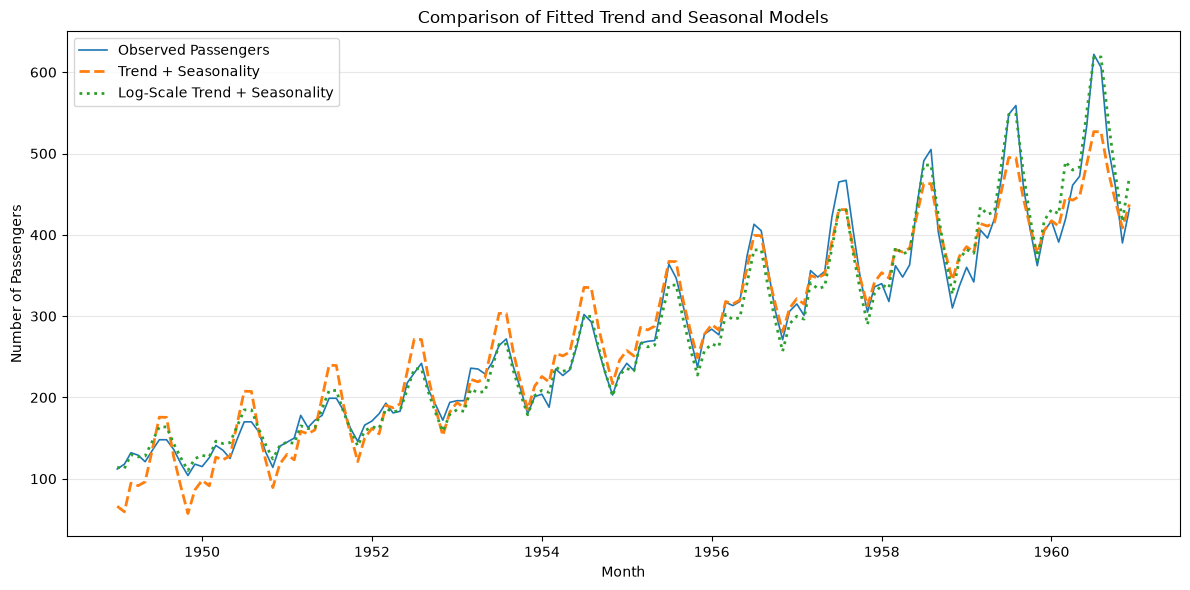

In [38]:
# 8.7 Compare the fitted models on the original passenger scale

plt.figure(figsize=(12, 6))

# Observed series
plt.plot(
    df['Month'],
    df['Passengers'],
    linewidth=1.2,
    label='Observed Passengers'
)

# Model 2: Trend + Seasonality
plt.plot(
    df['Month'],
    df['Seasonal_Fitted'],
    linewidth=2,
    linestyle='--',
    label='Trend + Seasonality'
)

# Model 3: Log-scale Trend + Seasonality
# Back-transformed to the original passenger scale
plt.plot(
    df['Month'],
    df['Log_Fitted_Passengers'],
    linewidth=2,
    linestyle=':',
    label='Log-Scale Trend + Seasonality'
)

plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Comparison of Fitted Trend and Seasonal Models')

plt.legend()

plt.grid(
    True,
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    'figures/model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 9. Model Comparison

# 9.1 Model comparison table

In [39]:
# 9.1 Model comparison table

model_comparison = pd.DataFrame({
    'Model': [
        'Trend Only',
        'Trend + Seasonality',
        'Log Trend + Seasonality'
    ],
    'Scale': [
        'Original',
        'Original',
        'Log'
    ],
    'R-squared': [
        trend_model.rsquared,
        seasonal_model.rsquared,
        log_seasonal_model.rsquared
    ],
    'Adjusted R-squared': [
        trend_model.rsquared_adj,
        seasonal_model.rsquared_adj,
        log_seasonal_model.rsquared_adj
    ],
    'AIC': [
        trend_model.aic,
        seasonal_model.aic,
        log_seasonal_model.aic
    ],
    'BIC': [
        trend_model.bic,
        seasonal_model.bic,
        log_seasonal_model.bic
    ]
})

model_comparison.round(4)

,Model,Scale,R-squared,Adjusted R-squared,AIC,BIC
0,Trend Only,Original,0.8536,0.8526,1513.6466,1519.5862
1,Trend + Seasonality,Original,0.9559,0.9518,1362.9966,1401.6042
2,Log Trend + Seasonality,Log,0.9835,0.9820,-392.5952,-353.9876


# 9.2 Residual diagnostics


In [40]:
# 9.2 Residual diagnostics

# Model 2: original-scale residuals
residual_acf_model2 = acf(
    df['Residual'],
    nlags=36,
    fft=False
)

# Model 3: log-scale residuals
residual_acf_model3 = acf(
    df['Log_Residual'],
    nlags=36,
    fft=False
)

residual_diagnostics = pd.DataFrame({
    'Model': [
        'Trend + Seasonality',
        'Log Trend + Seasonality'
    ],
    
    'ACF Lag 12': [
        residual_acf_model2[12],
        residual_acf_model3[12]
    ],
    
    'ACF Lag 24': [
        residual_acf_model2[24],
        residual_acf_model3[24]
    ],
    
    'ACF Lag 36': [
        residual_acf_model2[36],
        residual_acf_model3[36]
    ]
})

residual_diagnostics.round(4)

,Model,ACF Lag 12,ACF Lag 24,ACF Lag 36
0,Trend + Seasonality,0.5780,0.3460,0.1856
1,Log Trend + Seasonality,0.3531,0.0195,-0.1837


# 9.3 Error metrics for the log-scale model

In [41]:
# 9.3 Error metrics for the log-scale model

log_mae = np.mean(
    np.abs(df['Log_Residual'])
)

log_rmse = np.sqrt(
    np.mean(df['Log_Residual'] ** 2)
)

print("Log-Scale Model Error Metrics")
print("-----------------------------")
print(f"MAE (log scale): {log_mae:.4f}")
print(f"RMSE (log scale): {log_rmse:.4f}")

Log-Scale Model Error Metrics
-----------------------------
MAE (log scale): 0.0466
RMSE (log scale): 0.0566


In [42]:
# Check the fitted values of both models
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model 2: Trend + Seasonality
model2_mae_original = mean_absolute_error(
    df['Passengers'],
    df['Seasonal_Fitted']
)

model2_rmse_original = mean_squared_error(
    df['Passengers'],
    df['Seasonal_Fitted']
) ** 0.5

In [43]:
# Model 3: Log Trend + Seasonality
# Predictions have already been back-transformed
# to the original passenger scale.

model3_mae_original = mean_absolute_error(
    df['Passengers'],
    df['Log_Fitted_Passengers']
)

model3_rmse_original = mean_squared_error(
    df['Passengers'],
    df['Log_Fitted_Passengers']
) ** 0.5

In [44]:
print("Original-Scale Model Comparison")
print("--------------------------------")
print(
    f"Model 2 - MAE:  {model2_mae_original:.4f} passengers"
)
print(
    f"Model 2 - RMSE: {model2_rmse_original:.4f} passengers"
)

print()

print(
    f"Model 3 - MAE:  {model3_mae_original:.4f} passengers"
)
print(
    f"Model 3 - RMSE: {model3_rmse_original:.4f} passengers"
)

Original-Scale Model Comparison
--------------------------------
Model 2 - MAE:  19.7736 passengers
Model 2 - RMSE: 25.1136 passengers

Model 3 - MAE:  12.8920 passengers
Model 3 - RMSE: 16.7280 passengers


In [45]:
original_scale_comparison = pd.DataFrame({
    'Model': [
        'Trend + Seasonality',
        'Log Trend + Seasonality'
    ],
    'Scale': [
        'Original',
        'Back-transformed to Original'
    ],
    'MAE (passengers)': [
        model2_mae_original,
        model3_mae_original
    ],
    'RMSE (passengers)': [
        model2_rmse_original,
        model3_rmse_original
    ]
})

original_scale_comparison

,Model,Scale,MAE (passengers),RMSE (passengers)
0,Trend + Seasonality,Original,19.773644,25.113630
1,Log Trend + Seasonality,Back-transformed to Original,12.891958,16.728027


In [46]:
mae_change = (
    model2_mae_original - model3_mae_original
)

rmse_change = (
    model2_rmse_original - model3_rmse_original
)

print("Change in Original-Scale Error")
print("------------------------------")
print(f"MAE change:  {mae_change:.4f} passengers")
print(f"RMSE change: {rmse_change:.4f} passengers")

Change in Original-Scale Error
------------------------------
MAE change:  6.8817 passengers
RMSE change: 8.3856 passengers


### 10.3 Conclusion

The analysis of monthly air passenger data from 1949 to 1960 demonstrates both a strong deterministic upward trend and clear annual seasonality. Exploratory analysis shows that passenger numbers increase substantially over time while exhibiting recurring within-year fluctuations.

The linear trend model provides a useful description of the long-term movement, but incorporating monthly seasonal effects substantially improves the representation of the observed series. A log-scale transformation further improves the original-scale error metrics and reduces residual dependence at the main seasonal lags.

The final analysis therefore supports the use of a log-scale trend-plus-seasonality specification to represent the main systematic features of the series. However, the remaining residual autocorrelation indicates that additional temporal dynamics are present and are not fully captured by the deterministic regression model.